In [29]:

# ==============================
# Wage Prediction Model Notebook
# ==============================

# 1. Import Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [30]:
# 2. Load Data

file_path = "../data/wages_by_education_cleaned_v2.xlsx" # Replace with your file path

# 📥 Load the Excel file
try:
    # specify engine to ensure pandas uses openpyxl
    df = pd.read_excel(file_path, engine='openpyxl')

    print("File loaded successfully!")
    print(df.head())
    # Normalize EducationLevel labels
    df["EducationLevel"] = df["EducationLevel"].str.replace(" Degree", "", regex=False).str.title()
    # Show first few rows
    print(df.head())
    print(df.columns)  # Show column names
except FileNotFoundError:
    print("File not found. Double-check the path.")
except Exception as e:
    print(f"An error occurred: {e}")


File loaded successfully!
   EmployeeID  EmployeeAge EmployeeGender    CareerField CareerLevel  \
0           1           57         Female  Manufacturing       Entry   
1           2           57           Male    Engineering         Mid   
2           3           55           Male   Construction       Entry   
3           4           57           Male          Media       Entry   
4           5           57           Male    Real Estate         Mid   

   MonthlyIncome     EducationLevel  
0           4288   Associate Degree  
1           7090  Bachelor's Degree  
2           4734   Associate Degree  
3           7082    Master's Degree  
4           4753        High School  
   EmployeeID  EmployeeAge EmployeeGender    CareerField CareerLevel  \
0           1           57         Female  Manufacturing       Entry   
1           2           57           Male    Engineering         Mid   
2           3           55           Male   Construction       Entry   
3           4           5

In [31]:

# 3. Encode Categorical Features
career_encoder = LabelEncoder()
education_encoder = LabelEncoder()

df['CareerField_encoded'] = career_encoder.fit_transform(df['CareerField'])
df['EducationLevel_encoded'] = education_encoder.fit_transform(df['EducationLevel'])

# 4. Prepare Features and Target
X = df[['CareerField_encoded', 'EducationLevel_encoded']]
y = df['MonthlyIncome']


In [32]:
# 5. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [33]:
# 6. Initialize Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}


In [34]:
# 7. Train and Evaluate Models
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    results.append((name, mse, r2))
    print(f"{name} - MSE: {mse:.2f}, R²: {r2:.4f}")

Linear Regression - MSE: 2247609.54, R²: 0.3102
Decision Tree - MSE: 540208.02, R²: 0.8342
Random Forest - MSE: 539836.97, R²: 0.8343
Gradient Boosting - MSE: 536573.33, R²: 0.8353


In [35]:
# 8. Select Best Model (based on R²)
best_model_name, best_mse, best_r2 = max(results, key=lambda x: x[2])
best_model = models[best_model_name]
print(f"\n✅ Best Model: {best_model_name} (R² = {best_r2:.4f})")


✅ Best Model: Gradient Boosting (R² = 0.8353)


In [ ]:
# 9. Predict for User Input with Preset Options
# This cell includes robust mapping to the fitted LabelEncoders to avoid
# ValueError for unseen labels (e.g., different punctuation/casing).

# Career options (display-friendly)
career_options = {
    "1": "Construction",
    "2": "Media",
    "3": "Engineering",
    "4": "Education",
    "5": "Healthcare"
}

# Education options (display-friendly)
education_options = {
    "1": "High School",
    "2": "Associate's",
    "3": "Bachelor's",
    "4": "Master's",
    "5": "PhD"
}

# Helper to safely map a user label to an encoder class (with normalization & fallback)
def _normalize_label(s):
    import re
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

def safe_encode(encoder, label, df_column=None):
    """
    Try to transform `label` using the fitted LabelEncoder `encoder`.
    If the exact label isn't found, try normalized matching against encoder.classes_.
    If still not found, fall back to the most frequent label in df_column (if provided),
    otherwise fall back to the first class in encoder.classes_.
    """
    # direct match
    if label in encoder.classes_:
        return int(encoder.transform([label])[0])

    # normalized matching
    norm_map = { _normalize_label(c): c for c in encoder.classes_ }
    nl = _normalize_label(label)
    if nl in norm_map:
        return int(encoder.transform([norm_map[nl]])[0])

    # try partial containment match
    for c in encoder.classes_:
        if nl in _normalize_label(c) or _normalize_label(c) in nl:
            return int(encoder.transform([c])[0])

    # fallback to mode of original df column if provided
    fallback = None
    if df_column is not None and hasattr(df_column, "mode"):
        try:
            m = df_column.mode()
            if len(m) > 0:
                fallback = m.iloc[0]
        except Exception:
            fallback = None

    if fallback is None:
        fallback = encoder.classes_[0]

    print(f"Warning: '{label}' not recognized by encoder. Falling back to '{fallback}'.")
    return int(encoder.transform([fallback])[0])

# Display career choices
print("Select a career:")
for key, value in career_options.items():
    print(f"{key}: {value}")
career_choice = input("Enter the number for your career: ").strip()
career = career_options.get(career_choice, "Construction")  # Default fallback

# Display education choices
print("\nSelect an education level:")
for key, value in education_options.items():
    print(f"{key}: {value}")
education_choice = input("Enter the number for your education level: ").strip()
education = education_options.get(education_choice, "High School")  # Default fallback

# Encode using safe_encode (use df['EducationLevel'] and df['CareerField'] as fallback sources)
career_encoded = safe_encode(career_encoder, career, df['CareerField'] if 'df' in globals() else None)
education_encoded = safe_encode(education_encoder, education, df['EducationLevel'] if 'df' in globals() else None)

# Prepare input and predict
input_data = np.array([[career_encoded, education_encoded]])
predicted_income = best_model.predict(input_data)[0]

print(f"\nPredicted Monthly Income for {career} with {education}: ${predicted_income:.2f}")


Select a career:
1: Construction
2: Media
3: Engineering
4: Education
5: Healthcare

Select an education level:
1: High School
2: Associate's
3: Bachelor's
4: Master's
5: PhD

Predicted Monthly Income for Education with Master's: $8013.66


C:\Users\ceped\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


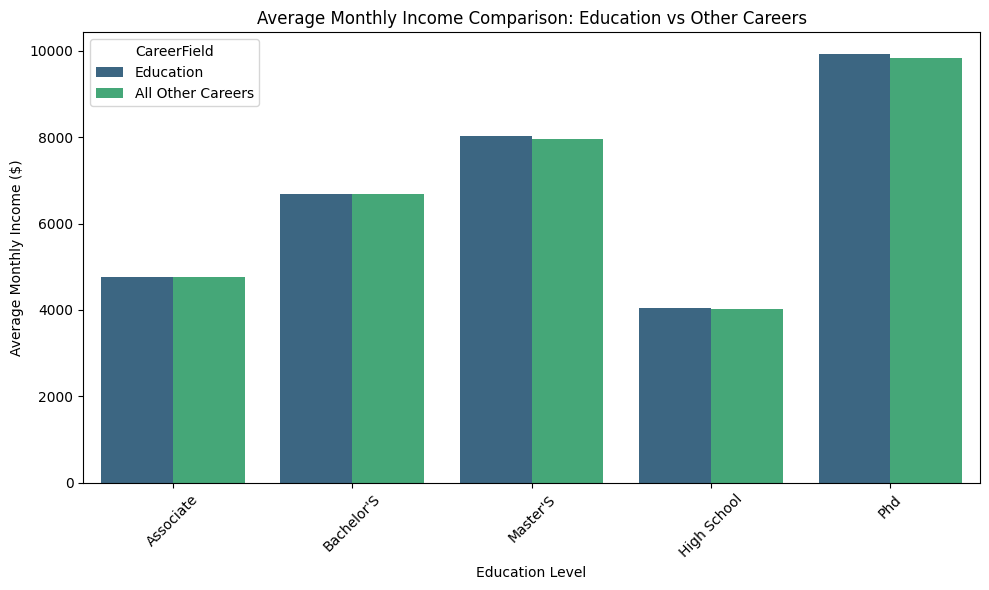

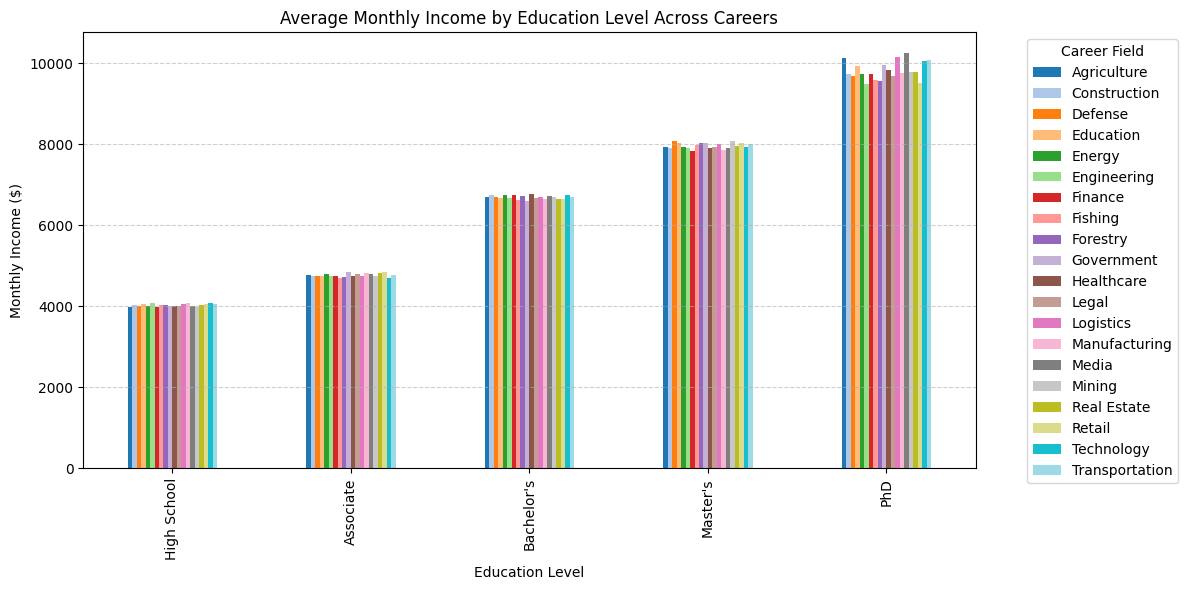


Predicted Monthly Income for Education with Master's: $8013.66


In [38]:
# 10. Visual Comparison for Selected Career
import matplotlib.pyplot as plt
import seaborn as sns


""" 		          IMPORTANT 				"""
"""This section creates a side-by-side bar chart comparing average monthly incomes and you only need to run this cell after running the previous cells."""
# Filter data for the selected career
career_data = df[df['CareerField'] == career]

# Compute average monthly income by education level for that career
career_avg = career_data.groupby('EducationLevel')['MonthlyIncome'].mean().reset_index()
career_avg['CareerField'] = career

# Compute overall averages for all other careers
others_avg = df[df['CareerField'] != career].groupby('EducationLevel')['MonthlyIncome'].mean().reset_index()
others_avg['CareerField'] = 'All Other Careers'

# Combine both datasets for comparison
compare_df = pd.concat([career_avg, others_avg])

# Sort education levels for a clean plot (optional)
education_order = df['EducationLevel'].unique()

# Create side-by-side bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=compare_df,
    x='EducationLevel',
    y='MonthlyIncome',
    hue='CareerField',
    order=education_order,
    palette='viridis'
)

plt.title(f"Average Monthly Income Comparison: {career} vs Other Careers")
plt.xlabel("Education Level")
plt.ylabel("Average Monthly Income ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

import re
import matplotlib.pyplot as plt

# Normalize education labels robustly to match the desired ordering
def normalize_education_label(val):
	if pd.isna(val):
		return val
	s = re.sub(r"\s*degree\s*$", "", str(val), flags=re.I).strip()
	sl = s.lower()
	if "high" in sl:
		return "High School"
	if "associate" in sl:
		return "Associate"
	if "bachelor" in sl:
		return "Bachelor's"
	if "master" in sl:
		return "Master's"
	if "phd" in sl or "ph.d" in sl:
		return "PhD"
	# fallback: title-case the cleaned string
	return s.title()

# Apply normalization (don't re-import or overwrite df; df exists in the notebook)
df["EducationLevel_normalized"] = df["EducationLevel"].apply(normalize_education_label)

# Define education order (exact labels must match normalized values)
education_order = ["High School", "Associate", "Bachelor's", "Master's", "PhD"]

# Filter only relevant columns and use the normalized education column
df_filtered = df[["CareerField", "EducationLevel_normalized", "MonthlyIncome"]].copy()
df_filtered = df_filtered.rename(columns={"EducationLevel_normalized": "EducationLevel"})

# Group and pivot (groupby + mean ensures unique (EducationLevel, CareerField) pairs)
grouped = df_filtered.groupby(["EducationLevel", "CareerField"], as_index=False)["MonthlyIncome"].mean()

# Create the pivot table and reindex rows to the desired education order (keeps order and avoids duplicate-index issues)
pivot_df = grouped.pivot(index="EducationLevel", columns="CareerField", values="MonthlyIncome")
pivot_df = pivot_df.reindex(education_order)  # this will keep the order and put NaN for missing levels

# Plot
pivot_df.plot(kind="bar", figsize=(12, 6), colormap="tab20")
plt.title("Average Monthly Income by Education Level Across Careers")
plt.xlabel("Education Level")
plt.ylabel("Monthly Income ($)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Career Field", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(f"\nPredicted Monthly Income for {career} with {education}: ${predicted_income:.2f}")
